In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Diego/Paper Interpretability')
print(os.getcwd())

/content/drive/MyDrive/Colab Notebooks/Diego/Paper Interpretability


In [ ]:
!pip install optuna
!pip install lime
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=85996e05cc51ca240b77dd016831403b655e75925e35e87d54fc88b79b75d751
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 5.6 MB/s eta 0:00:00


/tmp/ipykernel_676/2544697031.py:335: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_metric_group)


Available MI windows:
['0-7', '2.5-5']


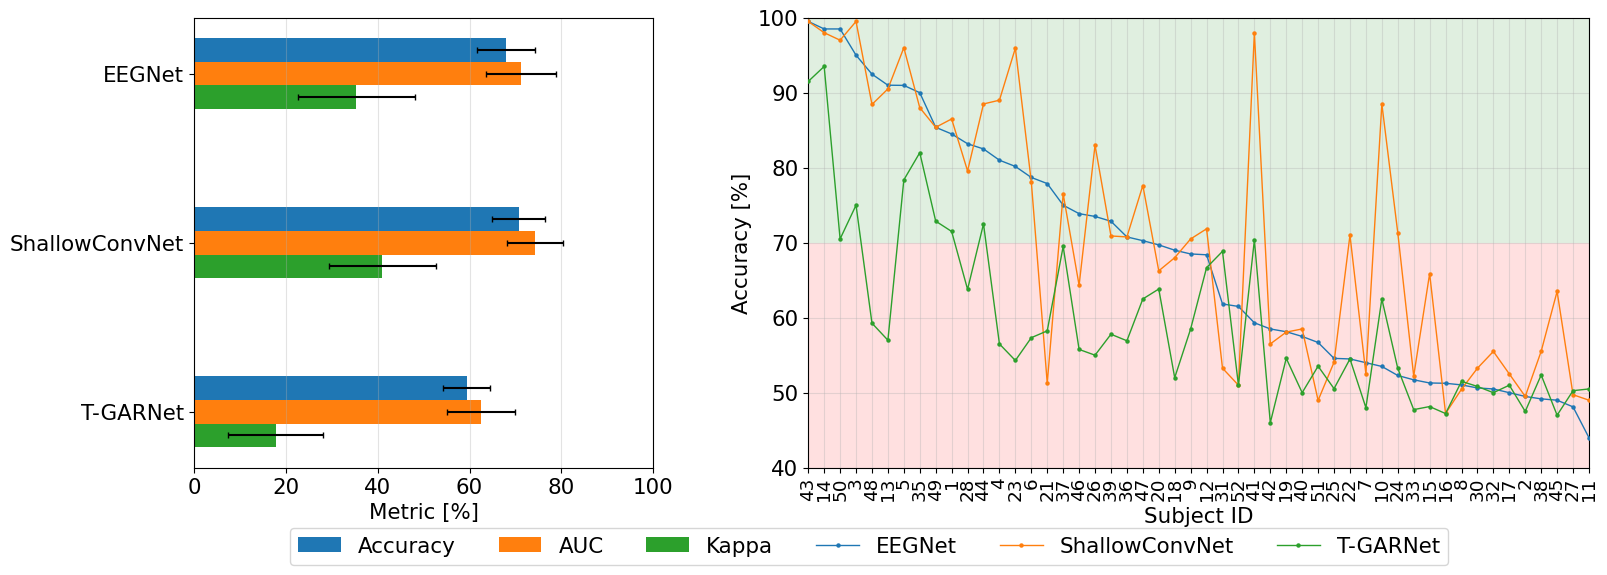

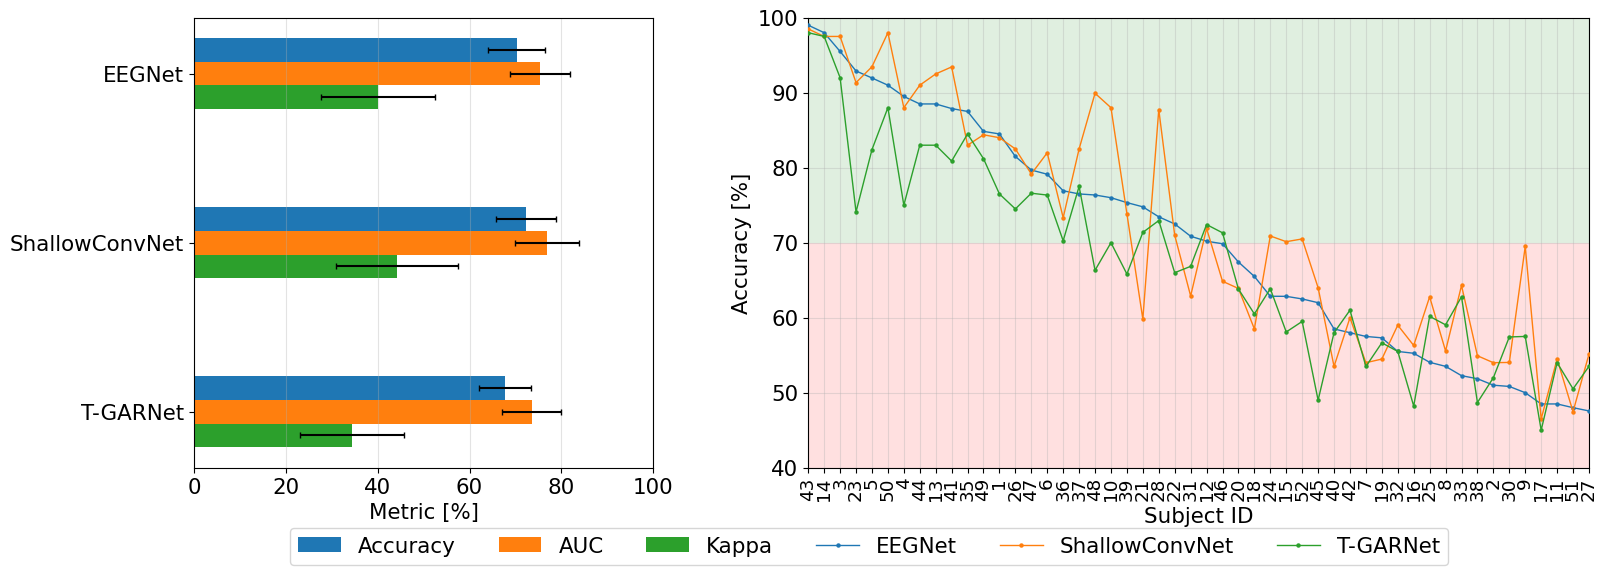

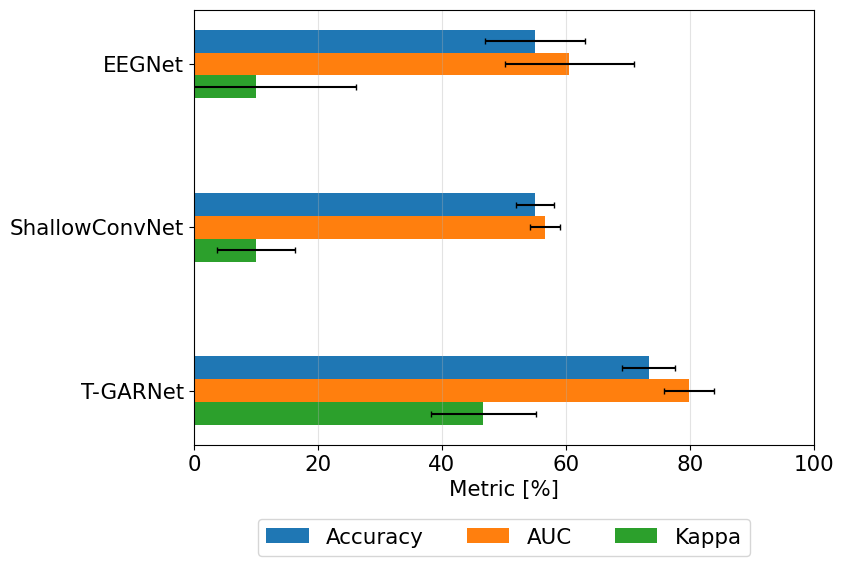

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    roc_auc_score
)

# ============================================================
# Paths
# ============================================================

mi_csv_path = "Results/MI_results.csv"
tdah_csv_path = "Results/TDAH_results.csv"

save_dir = "Figures"
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# Global configuration
# ============================================================

metrics = ["accuracy", "auc", "kappa"]

metric_labels = {
    "accuracy": "Accuracy",
    "auc": "AUC",
    "kappa": "Kappa"
}

model_label_map = {
    "shallowconvnet": "ShallowConvNet",
    "shallow": "ShallowConvNet",
    "eegnet": "EEGNet",
    "tgarnet": "T-GARNet",
    "t-garnet": "T-GARNet",
}

# ------------------------------------------------------------
# Font-size configuration
# ------------------------------------------------------------
# caption_fontsize_pt should match the approximate caption size
# used in the manuscript.
#
# figure_fontsize_pt controls general figure text:
# labels, ticks, model names, legend, etc.
#
# subject_id_fontsize_pt controls only the subject IDs on
# the x-axis of the MI subject-wise plots.

caption_fontsize_pt = 22

figure_fontsize_pt = 0.70 * caption_fontsize_pt
subject_id_fontsize_pt = 0.60 * caption_fontsize_pt

plt.rcParams.update({
    "font.size": figure_fontsize_pt,
    "axes.labelsize": figure_fontsize_pt,
    "xtick.labelsize": figure_fontsize_pt,
    "ytick.labelsize": figure_fontsize_pt,
    "legend.fontsize": figure_fontsize_pt,
    "axes.titlesize": figure_fontsize_pt,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def pretty_model_name(model):
    return model_label_map.get(str(model).lower(), str(model))


def to_percent(x):
    """
    Converts values from 0-1 to percentages.
    If values already seem to be in 0-100, they are left unchanged.
    """
    x = pd.to_numeric(x, errors="coerce")

    if x.dropna().empty:
        return x

    if x.dropna().abs().max() <= 1.5:
        return 100.0 * x

    return x


def clean_subject_column(df, subject_col="subject"):
    """
    Ensures that the subject column is sortable.
    Numeric subjects are converted to numbers; otherwise, they remain strings.
    """
    df = df.copy()

    try:
        df[subject_col] = pd.to_numeric(df[subject_col])
    except Exception:
        df[subject_col] = df[subject_col].astype(str)

    return df


# ============================================================
# Safe metrics for ADHD/TDAH
# ============================================================

def safe_auc(y_true, y_score):
    """
    Computes AUC safely.
    Returns NaN if only one class is present.
    """
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if len(np.unique(y_true)) < 2:
        return np.nan

    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan


def safe_metric_group(g):
    """
    Computes subject-level metrics for ADHD/TDAH.
    """
    y_true = g["true_class"].astype(int).values
    y_pred = g["pred_majority_class"].astype(int).values

    if "prob_class_1" in g.columns:
        y_score = pd.to_numeric(g["prob_class_1"], errors="coerce").values
    else:
        y_score = y_pred

    return pd.Series({
        "accuracy": accuracy_score(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "auc": safe_auc(y_true, y_score)
    })


# ============================================================
# MI summary: global bars
# ============================================================

def summarize_mi_global(mi_csv_path):
    """
    Summarizes MI metrics by window and model.

    Expected columns:
    window, model,
    mean_accuracy, std_accuracy,
    mean_auc, std_auc,
    mean_kappa, std_kappa
    """

    df_mi = pd.read_csv(mi_csv_path)

    required_cols = ["window", "model"]
    missing = [c for c in required_cols if c not in df_mi.columns]

    if missing:
        raise ValueError(f"Missing columns in MI_results.csv: {missing}")

    rows = []

    for metric in metrics:
        mean_col = f"mean_{metric}"
        std_col = f"std_{metric}"

        if mean_col not in df_mi.columns:
            raise ValueError(f"Missing column '{mean_col}' in MI_results.csv")

        if std_col not in df_mi.columns:
            raise ValueError(f"Missing column '{std_col}' in MI_results.csv")

        aux = (
            df_mi
            .groupby(["window", "model"], as_index=False)
            .agg(
                mean_value=(mean_col, "mean"),
                std_value=(std_col, "mean")
            )
        )

        aux["metric"] = metric
        rows.append(aux)

    summary = pd.concat(rows, ignore_index=True)

    summary["mean_value"] = to_percent(summary["mean_value"])
    summary["std_value"] = to_percent(summary["std_value"])

    return summary


# ============================================================
# MI summary: subject-level accuracy
# ============================================================

def summarize_mi_subject_level(mi_csv_path):
    """
    Summarizes MI accuracy by window, model, and subject.

    Expected columns:
    window, model, subject, mean_accuracy, std_accuracy
    """

    df_mi = pd.read_csv(mi_csv_path)
    df_mi = clean_subject_column(df_mi, "subject")

    required_cols = [
        "window",
        "model",
        "subject",
        "mean_accuracy",
        "std_accuracy"
    ]

    missing = [c for c in required_cols if c not in df_mi.columns]

    if missing:
        raise ValueError(f"Missing columns in MI_results.csv: {missing}")

    summary = (
        df_mi
        .groupby(["window", "model", "subject"], as_index=False)
        .agg(
            acc_mean=("mean_accuracy", "mean"),
            acc_std=("std_accuracy", "mean")
        )
    )

    summary["acc_mean"] = to_percent(summary["acc_mean"])
    summary["acc_std"] = to_percent(summary["acc_std"])

    return summary


def get_subject_order_by_eegnet(
    data,
    reference_model="EEGNet",
    subject_col="subject",
    acc_col="acc_mean",
    ascending=False
):
    """
    Orders subjects according to EEGNet accuracy.

    ascending=False:
        Highest EEGNet accuracy first.
    """

    data = data.copy()

    ref_mask = (
        data["model"]
        .astype(str)
        .str.lower()
        .eq(reference_model.lower())
    )

    ref_data = data[ref_mask].copy()

    if ref_data.empty:
        raise ValueError(
            f"Reference model '{reference_model}' was not found. "
            f"Available models: {sorted(data['model'].dropna().unique())}"
        )

    ref_order = (
        ref_data
        .groupby(subject_col, as_index=False)
        .agg(ref_acc=(acc_col, "mean"))
        .sort_values("ref_acc", ascending=ascending)
    )

    subject_order = ref_order[subject_col].tolist()

    remaining_subjects = [
        s for s in data[subject_col].unique()
        if s not in subject_order
    ]

    return subject_order + remaining_subjects


# ============================================================
# TDAH summary: global bars
# ============================================================

def summarize_tdah_global(tdah_csv_path):
    """
    Computes ADHD/TDAH metrics using one prediction per subject.

    Expected columns:
    model, repeat, fold, model_seed, subject,
    true_class, pred_majority_class, prob_class_1
    """

    df_tdah = pd.read_csv(tdah_csv_path)

    required_cols = [
        "model",
        "repeat",
        "fold",
        "model_seed",
        "subject",
        "true_class",
        "pred_majority_class",
        "prob_class_1"
    ]

    missing = [c for c in required_cols if c not in df_tdah.columns]

    if missing:
        raise ValueError(f"Missing columns in TDAH_results.csv: {missing}")

    df_subject = (
        df_tdah
        .sort_values(["model", "repeat", "fold", "model_seed", "subject"])
        .drop_duplicates(
            subset=["model", "repeat", "fold", "model_seed", "subject"],
            keep="last"
        )
    )

    tdah_fold_metrics = (
        df_subject
        .groupby(["model", "repeat", "fold", "model_seed"])
        .apply(safe_metric_group)
        .reset_index()
    )

    rows = []

    for metric in metrics:
        aux = (
            tdah_fold_metrics
            .groupby("model", as_index=False)
            .agg(
                mean_value=(metric, "mean"),
                std_value=(metric, "std")
            )
        )

        aux["metric"] = metric
        rows.append(aux)

    summary = pd.concat(rows, ignore_index=True)

    summary["window"] = "TDAH"
    summary["mean_value"] = to_percent(summary["mean_value"])
    summary["std_value"] = to_percent(summary["std_value"])

    return summary, tdah_fold_metrics


# ============================================================
# Plot: bar panel
# ============================================================

def plot_bar_panel(
    ax,
    data,
    model_order=None,
    metric_order=None,
    show_yticks=True,
    show_xlabel=True
):
    """
    Horizontal bar plot for metrics by model.
    """

    if metric_order is None:
        metric_order = metrics

    if model_order is None:
        model_order = list(data["model"].dropna().unique())

    n_models = len(model_order)
    n_metrics = len(metric_order)

    y = np.arange(n_models)
    bar_height = 0.14

    offsets = (
        np.arange(n_metrics) - (n_metrics - 1) / 2
    ) * bar_height

    for j, metric in enumerate(metric_order):
        sub = data[data["metric"] == metric].copy()

        means = []
        stds = []

        for model in model_order:
            row = sub[sub["model"] == model]

            if row.empty:
                means.append(np.nan)
                stds.append(np.nan)
            else:
                means.append(row["mean_value"].values[0])
                stds.append(row["std_value"].values[0])

        ax.barh(
            y + offsets[j],
            means,
            height=bar_height,
            xerr=stds,
            capsize=2,
            label=metric_labels.get(metric, metric)
        )

    if show_yticks:
        ax.set_yticks(y)
        ax.set_yticklabels([pretty_model_name(m) for m in model_order])
    else:
        ax.set_yticks([])
        ax.set_yticklabels([])

    if show_xlabel:
        ax.set_xlabel("Metric [%]")
    else:
        ax.set_xlabel("")

    ax.set_xlim(0, 100)
    ax.grid(axis="x", alpha=0.35)
    ax.invert_yaxis()

    ax.tick_params(axis="both", labelsize=figure_fontsize_pt)


# ============================================================
# Plot: subject-level MI panel
# ============================================================

def plot_subject_acc_panel(
    ax,
    data,
    subject_order=None,
    model_order=None,
    show_std=False,
    xtick_fontsize=None,
    show_yticks=True,
    show_ylabel=True,
    show_xlabel=True
):
    """
    Plots subject-level accuracy for MI.
    """

    data = data.copy()

    if xtick_fontsize is None:
        xtick_fontsize = subject_id_fontsize_pt

    if subject_order is None:
        subject_order = get_subject_order_by_eegnet(data)

    if model_order is None:
        model_order = sorted(data["model"].dropna().unique())

    x = np.arange(len(subject_order))

    # Performance bands
    ax.axhspan(70, 100, facecolor="green", alpha=0.12, zorder=0)
    ax.axhspan(0, 70, facecolor="red", alpha=0.12, zorder=0)

    for model in model_order:
        sub = data[data["model"] == model].copy()

        sub = (
            sub
            .set_index("subject")
            .reindex(subject_order)
            .reset_index()
        )

        y = sub["acc_mean"].values
        yerr = sub["acc_std"].values

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=1.0,
            markersize=2.2,
            label=pretty_model_name(model),
            zorder=3
        )

        if show_std:
            ax.fill_between(
                x,
                y - yerr,
                y + yerr,
                alpha=0.15,
                zorder=2
            )

    if show_xlabel:
        ax.set_xlabel("Subject ID")
    else:
        ax.set_xlabel("")

    if show_ylabel:
        ax.set_ylabel("Accuracy [%]")
    else:
        ax.set_ylabel("")

    ax.set_ylim(40, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(
        subject_order,
        rotation=90,
        fontsize=xtick_fontsize
    )

    if len(x) > 0:
        ax.set_xlim(x[0], x[-1])

    if show_yticks:
        ax.tick_params(axis="y", labelleft=True, labelsize=figure_fontsize_pt)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", labelleft=False)

    # Important:
    # This controls only the subject ID numbers on the x-axis.
    ax.tick_params(axis="x", labelsize=xtick_fontsize)

    ax.grid(True, alpha=0.35, zorder=1)
    ax.set_axisbelow(True)


# ============================================================
# Figure 1 and 2: MI window with two columns
# ============================================================

def plot_mi_window_figure(
    window_name,
    mi_global_summary,
    mi_subject_summary,
    save_path=None,
    reference_model="EEGNet"
):
    """
    Generates one MI figure with:
    column 1: global metric bars
    column 2: subject-level accuracy.
    """

    data_bar = mi_global_summary[
        mi_global_summary["window"].astype(str) == str(window_name)
    ].copy()

    data_subject = mi_subject_summary[
        mi_subject_summary["window"].astype(str) == str(window_name)
    ].copy()

    if data_bar.empty:
        raise ValueError(f"No global MI data found for window '{window_name}'.")

    if data_subject.empty:
        raise ValueError(f"No subject-level MI data found for window '{window_name}'.")

    model_order = list(data_bar["model"].dropna().unique())

    subject_order = get_subject_order_by_eegnet(
        data=data_subject,
        reference_model=reference_model,
        ascending=False
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(18, 6),
        gridspec_kw={"width_ratios": [1.0, 1.7]}
    )

    plot_bar_panel(
        ax=axes[0],
        data=data_bar,
        model_order=model_order,
        metric_order=metrics,
        show_yticks=True,
        show_xlabel=True
    )

    plot_subject_acc_panel(
        ax=axes[1],
        data=data_subject,
        subject_order=subject_order,
        model_order=model_order,
        show_std=False,
        xtick_fontsize=subject_id_fontsize_pt,
        show_yticks=True,
        show_ylabel=True,
        show_xlabel=True
    )

    # --------------------------------------------------------
    # Global legend
    # --------------------------------------------------------
    all_handles = []
    all_labels = []

    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()

        for h, l in zip(handles, labels):
            if l not in all_labels:
                all_handles.append(h)
                all_labels.append(l)

        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    fig.legend(
        all_handles,
        all_labels,
        loc="lower center",
        ncol=min(len(all_labels), 6),
        fontsize=figure_fontsize_pt,
        frameon=True,
        bbox_to_anchor=(0.5, 0.02)
    )

    fig.subplots_adjust(
        bottom=0.20,
        top=0.95,
        wspace=0.25
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# ============================================================
# Figure 3: ADHD/TDAH bars only
# ============================================================

def plot_tdah_bar_figure(
    tdah_summary,
    save_path=None
):
    """
    Generates the ADHD/TDAH figure with only the global bar diagram.
    """

    data_bar = tdah_summary.copy()

    if data_bar.empty:
        raise ValueError("No ADHD/TDAH data found.")

    model_order = list(data_bar["model"].dropna().unique())

    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8, 5)
    )

    plot_bar_panel(
        ax=ax,
        data=data_bar,
        model_order=model_order,
        metric_order=metrics,
        show_yticks=True,
        show_xlabel=True
    )

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(labels),
        fontsize=figure_fontsize_pt,
        frameon=True,
        bbox_to_anchor=(0.5, -0.28)
    )

    fig.subplots_adjust(
        bottom=0.08,
        top=0.95
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# ============================================================
# Run
# ============================================================

mi_global_summary = summarize_mi_global(mi_csv_path)
mi_subject_summary = summarize_mi_subject_level(mi_csv_path)

tdah_summary, tdah_fold_metrics = summarize_tdah_global(tdah_csv_path)

# ------------------------------------------------------------
# Check available MI windows
# ------------------------------------------------------------

available_windows = sorted(mi_global_summary["window"].dropna().astype(str).unique())

print("Available MI windows:")
print(available_windows)

# ------------------------------------------------------------
# Figure 1: MI 0-7 seconds
# ------------------------------------------------------------

plot_mi_window_figure(
    window_name="0-7",
    mi_global_summary=mi_global_summary,
    mi_subject_summary=mi_subject_summary,
    save_path=os.path.join(save_dir, "Cl_MI_0_7.pdf"),
    reference_model="EEGNet"
)

# ------------------------------------------------------------
# Figure 2: MI 2.5-5 seconds
# ------------------------------------------------------------

plot_mi_window_figure(
    window_name="2.5-5",
    mi_global_summary=mi_global_summary,
    mi_subject_summary=mi_subject_summary,
    save_path=os.path.join(save_dir, "Cl_MI_2_5_5.pdf"),
    reference_model="EEGNet"
)

# ------------------------------------------------------------
# Figure 3: ADHD/TDAH
# ------------------------------------------------------------

plot_tdah_bar_figure(
    tdah_summary=tdah_summary,
    save_path=os.path.join(save_dir, "Cl_TDAH.pdf")
)

In [ ]:
# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.stats import rankdata, ttest_ind
# import matplotlib.patheffects as pe

# mi_csv_path = "Results/MI_results.csv"
# tdah_csv_path = "Results/TDAH_results.csv"

# mi_subject_summary = summarize_mi_subject_level(mi_csv_path)


# desired_blocks = [
#     ("MI 2.5-5", "2.5-5", "subject"),
#     ("MI 0-7",   "0-7",   "subject"),
#     ("TDAH",     "TDAH",  "fold"),
# ]

# model_order = ["eegnet", "shallowconvnet", "tgarnet"]

# model_label_map = {
#     "eegnet": "EEGNet",
#     "shallowconvnet": "ShallowConvNet",
#     "shallow": "ShallowConvNet",
#     "tgarnet": "T-GARNet",
#     "t-garnet": "T-GARNet",
# }


# def pretty_model_name(model):
#     return model_label_map.get(str(model).lower(), str(model))

# def summarize_tdah_fold_level(tdah_csv_path):
#     """
#     Calcula accuracy por fold y modelo para TDAH.

#     Si existe columna accuracy, la usa directamente.
#     Si no existe, calcula accuracy usando true_class vs pred_majority_class.

#     Salida:
#         model, fold, acc_mean, acc_std
#     """

#     df = pd.read_csv(tdah_csv_path).copy()

#     required_base = ["model", "fold"]
#     missing_base = [c for c in required_base if c not in df.columns]

#     if missing_base:
#         raise ValueError(f"Faltan columnas en TDAH_results.csv: {missing_base}")

#     df["model_key"] = df["model"].astype(str).str.lower()

#     if "accuracy" in df.columns:

#         df["accuracy"] = to_percent(df["accuracy"])

#         summary = (
#             df
#             .groupby(["model", "fold"], as_index=False)
#             .agg(
#                 acc_mean=("accuracy", "mean"),
#                 acc_std=("accuracy", "std")
#             )
#         )

#     else:

#         required_cols = [
#             "model",
#             "repeat",
#             "fold",
#             "model_seed",
#             "subject",
#             "true_class",
#             "pred_majority_class"
#         ]

#         missing = [c for c in required_cols if c not in df.columns]

#         if missing:
#             raise ValueError(
#                 "No existe columna 'accuracy' y tampoco están las columnas "
#                 f"necesarias para calcularla: {missing}"
#             )

#         df = (
#             df
#             .sort_values(["model", "repeat", "fold", "model_seed", "subject"])
#             .drop_duplicates(
#                 subset=["model", "repeat", "fold", "model_seed", "subject"],
#                 keep="last"
#             )
#             .copy()
#         )

#         df["true_class"] = df["true_class"].astype(int)
#         df["pred_majority_class"] = df["pred_majority_class"].astype(int)

#         df["correct"] = (
#             df["true_class"] == df["pred_majority_class"]
#         ).astype(float)

#         # Accuracy por ejecución, modelo y fold
#         run_fold_acc = (
#             df
#             .groupby(["model", "repeat", "model_seed", "fold"], as_index=False)
#             .agg(
#                 accuracy=("correct", "mean"),
#                 n_subjects=("subject", "nunique")
#             )
#         )

#         run_fold_acc["accuracy"] = 100.0 * run_fold_acc["accuracy"]

#         # Promedio final por modelo y fold
#         summary = (
#             run_fold_acc
#             .groupby(["model", "fold"], as_index=False)
#             .agg(
#                 acc_mean=("accuracy", "mean"),
#                 acc_std=("accuracy", "std")
#             )
#         )

#     summary["acc_std"] = summary["acc_std"].fillna(0.0)
#     summary["window"] = "TDAH"

#     return summary


# tdah_fold_summary = summarize_tdah_fold_level(tdah_csv_path)

# def rankings_by_unit(pivot):
#     """
#     Calcula ranking por unidad.

#     Para MI:
#         unidad = subject

#     Para TDAH:
#         unidad = fold

#     Entrada:
#         pivot:
#             index   = modelos
#             columns = sujetos o folds
#             values  = accuracy

#     Salida:
#         DataFrame con ranking por unidad.
#         Ranking 1 = mejor accuracy.
#     """

#     ranks = pivot.copy().astype(float)

#     for col in ranks.columns:
#         values = ranks[col].values.astype(float)
#         mask = ~np.isnan(values)

#         r = np.full_like(values, np.nan, dtype=float)

#         if mask.sum() > 0:
#             r[mask] = rankdata(-values[mask], method="average")

#         ranks[col] = r

#     return ranks


# def ttest_matrix(pivot):
#     """
#     Calcula matriz de p-values usando t-test de Welch entre modelos.

#     Entrada:
#         pivot:
#             index   = modelos
#             columns = sujetos o folds
#             values  = accuracy
#     """

#     models = pivot.index.tolist()

#     P = pd.DataFrame(
#         np.ones((len(models), len(models))),
#         index=models,
#         columns=models
#     )

#     for i, m1 in enumerate(models):
#         for j, m2 in enumerate(models):

#             if i == j:
#                 P.loc[m1, m2] = 1.0
#                 continue

#             x = pivot.loc[m1].dropna().values.astype(float)
#             y = pivot.loc[m2].dropna().values.astype(float)

#             if len(x) < 2 or len(y) < 2:
#                 P.loc[m1, m2] = np.nan
#                 continue

#             _, p_value = ttest_ind(
#                 x,
#                 y,
#                 equal_var=False,
#                 nan_policy="omit"
#             )

#             P.loc[m1, m2] = p_value

#     return P

# def prepare_stats_df(data, unit_col):
#     """
#     Convierte el resumen al formato general:
#         Model, Unit, Accuracy_mean

#     Para MI:
#         unit_col = "subject"

#     Para TDAH:
#         unit_col = "fold"
#     """

#     df = data.copy()

#     df["model_key"] = df["model"].astype(str).str.lower()
#     df = df[df["model_key"].isin(model_order)].copy()

#     df["Model"] = df["model_key"].map(pretty_model_name)
#     df["Unit"] = df[unit_col]
#     df["Accuracy_mean"] = df["acc_mean"]

#     return df[["Model", "Unit", "Accuracy_mean"]]


# def make_pivot_single(data, unit_col):
#     """
#     Pivot:
#         filas    = modelos
#         columnas = sujetos o folds
#         valores  = Accuracy_mean
#     """

#     df = prepare_stats_df(data, unit_col=unit_col)

#     row_order = [
#         pretty_model_name(m)
#         for m in model_order
#         if pretty_model_name(m) in df["Model"].unique()
#     ]

#     try:
#         units = sorted(pd.unique(df["Unit"]).astype(int).tolist())
#     except Exception:
#         units = sorted(pd.unique(df["Unit"]).tolist(), key=lambda x: str(x))

#     pivot = (
#         df
#         .pivot_table(
#             index="Model",
#             columns="Unit",
#             values="Accuracy_mean",
#             aggfunc="mean"
#         )
#         .reindex(index=row_order, columns=units)
#     )

#     return pivot, row_order, units


# def plot_row_single(ax_rank, ax_p, data, unit_col, x_label="Subjects"):
#     """
#     Panel izquierdo:
#         ranking por sujeto o fold.

#     Panel derecho:
#         matriz de p-values Welch t-test.
#     """

#     fs_models = 18
#     fs_units = 14
#     fs_xlabel = 18
#     fs_cbar = 16
#     fs_cbar_ticks = 15
#     fs_pvalues = 14

#     pivot, row_order, units = make_pivot_single(
#         data=data,
#         unit_col=unit_col
#     )

#     ranks = rankings_by_unit(pivot)
#     P = ttest_matrix(pivot)

#     im1 = ax_rank.imshow(
#         ranks.values,
#         aspect="auto",
#         cmap="viridis_r",
#         vmin=1,
#         vmax=len(row_order)
#     )

#     ax_rank.set_yticks(np.arange(len(row_order)))
#     ax_rank.set_yticklabels(row_order, fontsize=fs_models)

#     ax_rank.set_xticks(np.arange(len(units)))
#     ax_rank.set_xticklabels(
#         units,
#         rotation=90,
#         fontsize=fs_units
#     )

#     ax_rank.set_xlabel(x_label, fontsize=fs_xlabel)

#     cbar1 = plt.colorbar(im1, ax=ax_rank, fraction=0.046, pad=0.02)
#     cbar1.set_label("Ranking", rotation=90, fontsize=fs_cbar)
#     cbar1.ax.tick_params(labelsize=fs_cbar_ticks)

#     im2 = ax_p.imshow(
#         P.values,
#         aspect="auto",
#         cmap="viridis_r",
#         vmin=0,
#         vmax=1
#     )

#     ax_p.set_xticks(np.arange(len(row_order)))
#     ax_p.set_yticks(np.arange(len(row_order)))

#     ax_p.set_xticklabels(
#         row_order,
#         rotation=90,
#         ha="right",
#         fontsize=fs_models
#     )

#     ax_p.set_yticklabels(
#         row_order,
#         fontsize=fs_models
#     )

#     ax_p.set_xlabel("")
#     ax_p.set_ylabel("")

#     cbar2 = plt.colorbar(im2, ax=ax_p, fraction=0.046, pad=0.02)
#     cbar2.set_label("p-value", rotation=90, fontsize=fs_cbar)
#     cbar2.ax.tick_params(labelsize=fs_cbar_ticks)

#     for i in range(P.shape[0]):
#         for j in range(P.shape[1]):
#             val = P.iloc[i, j]

#             if not pd.isna(val):

#                 txt_color = "white" if val < 0.5 else "black"
#                 edge_color = "black" if val < 0.5 else "white"

#                 ax_p.text(
#                     j,
#                     i,
#                     f"{val:.3f}",
#                     ha="center",
#                     va="center",
#                     fontsize=fs_pvalues,
#                     color=txt_color,
#                     fontweight="bold",
#                     path_effects=[
#                         pe.withStroke(linewidth=2, foreground=edge_color)
#                     ]
#                 )

# def build_avg_table_single(data, block_name, unit_col):
#     """
#     Tabla:
#         Block
#         Model
#         Avg. Ranking
#         Avg. t-test p-Value
#     """

#     pivot, _, _ = make_pivot_single(
#         data=data,
#         unit_col=unit_col
#     )

#     ranks = rankings_by_unit(pivot)
#     avg_rank = ranks.mean(axis=1, skipna=True)

#     P = ttest_matrix(pivot).copy()
#     np.fill_diagonal(P.values, np.nan)

#     avg_p = P.mean(axis=1, skipna=True)

#     table = (
#         pd.DataFrame({
#             "Block": block_name,
#             "Model": avg_rank.index,
#             "Avg. Ranking": avg_rank.values,
#             "Avg. t-test p-Value": avg_p.loc[avg_rank.index].values
#         })
#         .sort_values("Avg. Ranking")
#         .reset_index(drop=True)
#     )

#     return table.round({
#         "Avg. Ranking": 2,
#         "Avg. t-test p-Value": 4
#     })


# available_windows = list(mi_subject_summary["window"].dropna().unique())

# for _, w, unit_col in desired_blocks[:2]:
#     if w not in available_windows:
#         print("Ventanas disponibles en MI:")
#         print(available_windows)
#         raise ValueError(
#             f"No se encontró la ventana '{w}'. "
#             "Ajusta desired_blocks con el nombre exacto del CSV."
#         )

# data_blocks = []

# for block_name, window, unit_col in desired_blocks:

#     if window == "TDAH":
#         data_block = tdah_fold_summary.copy()
#         x_label = "Folds"
#     else:
#         data_block = mi_subject_summary[
#             mi_subject_summary["window"] == window
#         ].copy()
#         x_label = "Subjects"

#     data_blocks.append(
#         (block_name, data_block, unit_col, x_label)
#     )

# fig, axes = plt.subplots(
#     3,
#     2,
#     figsize=(20, 15),
#     gridspec_kw={
#         "width_ratios": [5.2, 1.3]
#     }
# )

# fig.subplots_adjust(
#     wspace=0.12,
#     hspace=0.40
# )

# for row_idx, (block_name, data_block, unit_col, x_label) in enumerate(data_blocks):

#     plot_row_single(
#         ax_rank=axes[row_idx, 0],
#         ax_p=axes[row_idx, 1],
#         data=data_block,
#         unit_col=unit_col,
#         x_label=x_label
#     )

# plt.tight_layout(rect=[0.08, 0.04, 1, 0.98])

# plt.savefig(
#     "stats_results_MI_TDAH.pdf",
#     format="pdf",
#     bbox_inches="tight"
# )

# plt.show()


# # ============================================================
# # 10. Tabla final con 3 bloques
# # ============================================================

# tables = []

# for block_name, data_block, unit_col, x_label in data_blocks:
#     tables.append(
#         build_avg_table_single(
#             data=data_block,
#             block_name=block_name,
#             unit_col=unit_col
#         )
#     )

# table_all = pd.concat(tables, axis=0, ignore_index=True)

# print("=== Summary table: MI 2.5-5, MI 0-7 and TDAH ===")
# print(table_all.to_string(index=False))